<a href="https://colab.research.google.com/github/NoeliaFerrero/Comi-96160-Data-Science-II-Machine-Learning-para-la-Ciencia-de-Datos-Diplomaturas/blob/main/Semana%205%20Apis%20y%20Data%20Wrangling/API_Terremotos_Data_Wrangling_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌎 APIs + Data Wrangling: ¿Qué nos cuentan los terremotos?

### Una práctica de Data Science con datos reales

En esta clase vamos a trabajar con una API pública de **USGS (United States Geological Survey)** para obtener información real sobre terremotos.

La idea es recorrer un pipeline completo:

```text
🌎 API de terremotos
        ↓
📦 JSON
        ↓
🐼 DataFrame
        ↓
🧹 Data Wrangling
        ↓
➕ concat()
        ↓
🔗 merge()
        ↓
📊 Análisis
        ↓
💡 Preguntas de negocio / ciencia
```

Y lo mejor: **no necesitamos una API Key**.

## 🎯 Objetivos

Al finalizar la práctica vas a poder:

- entender qué es una API;
- realizar una petición HTTP con `requests`;
- interpretar una respuesta JSON;
- transformar JSON en un DataFrame;
- limpiar y transformar datos;
- concatenar DataFrames con `concat()`;
- combinar información con `merge()`;
- crear variables derivadas;
- responder preguntas a partir de datos reales;
- realizar una visualización sencilla.

> **La API es real. Los datos son reales. El objetivo de la práctica es educativo.**

# 1. 🌎 El problema

Imaginemos que queremos estudiar la actividad sísmica reciente.

Nos interesan preguntas como:

### 🔎 Preguntas que podemos responder

- ¿Cuántos terremotos ocurrieron?
- ¿Cuál fue el de mayor magnitud?
- ¿Dónde ocurrieron?
- ¿Cuántos fueron considerados fuertes?
- ¿Qué relación existe entre magnitud y profundidad?
- ¿Qué zonas tuvieron mayor actividad?

Para responderlas necesitamos datos.

Y una forma de obtener datos automáticamente es mediante una **API**.

# 2. 🚪 ¿Qué es una API?

Una API puede pensarse como una **puerta de acceso a datos o funcionalidades**.

Nosotros hacemos una petición:

```text
GET → "Dame los terremotos de los últimos días"
```

La API responde:

```text
JSON → datos
```

Nuestro trabajo como DS empieza después:

```text
API → JSON → Pandas → análisis
```

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 3. 📡 Nuestra primera consulta

USGS ofrece una API pública de terremotos.

Vamos a pedir:

- terremotos de los últimos 14 días;
- magnitud mínima de 2.5;
- formato GeoJSON.

La URL se arma con parámetros, en lugar de escribir todos los valores manualmente.

In [3]:
from datetime import datetime, timedelta, timezone

hoy = datetime.now(timezone.utc)
fecha_inicio = hoy - timedelta(days=14)

url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

params = {
    "format": "geojson",
    "starttime": fecha_inicio.strftime("%Y-%m-%d"),
    "endtime": hoy.strftime("%Y-%m-%d"),
    "minmagnitude": 2.5,
    "limit": 20000
}

respuesta = requests.get(url, params=params)

print("Status code:", respuesta.status_code)
print("URL consultada:")
print(respuesta.url)

Status code: 200
URL consultada:
https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2026-07-27&endtime=2026-08-10&minmagnitude=2.5&limit=20000


## 🧠 El famoso Status Code

Si vemos:

```text
200
```

la solicitud fue procesada correctamente.

Otros códigos que podemos encontrar en APIs:

```text
200 → OK
400 → Bad Request
401 → Unauthorized
404 → Not Found
500 → Error del servidor
```

No hace falta memorizar todos ahora. Lo importante es **aprender a mirar qué respondió la API**.

# 4. 📦 Miramos el JSON

Ahora vamos a convertir la respuesta HTTP en un objeto Python.

In [4]:
datos = respuesta.json()

print(type(datos))
print(datos.keys())

<class 'dict'>
dict_keys(['type', 'metadata', 'features', 'bbox'])


La respuesta tiene una estructura parecida a:

```text
{
    "type": "FeatureCollection",
    "metadata": {...},
    "features": [...]
}
```

Nos interesa especialmente:

```text
features
```

porque allí está cada terremoto.

In [5]:
print("Cantidad de terremotos:", len(datos["features"]))

datos["features"][0]

Cantidad de terremotos: 950


{'type': 'Feature',
 'properties': {'mag': 4.3,
  'place': '15 km S of Antikyra, Greece',
  'time': 1786319819955,
  'updated': 1786337368040,
  'tz': None,
  'url': 'https://earthquake.usgs.gov/earthquakes/eventpage/us6000tjif',
  'detail': 'https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us6000tjif&format=geojson',
  'felt': None,
  'cdi': None,
  'mmi': None,
  'alert': None,
  'status': 'reviewed',
  'tsunami': 0,
  'sig': 284,
  'net': 'us',
  'code': '6000tjif',
  'ids': ',us6000tjif,',
  'sources': ',us,',
  'types': ',origin,phase-data,',
  'nst': 26,
  'dmin': 0.805,
  'rms': 0.82,
  'gap': 74,
  'magType': 'mb',
  'type': 'earthquake',
  'title': 'M 4.3 - 15 km S of Antikyra, Greece'},
 'geometry': {'type': 'Point', 'coordinates': [22.6168, 38.246, 10]},
 'id': 'us6000tjif'}

# 5. 🐼 JSON → DataFrame

Cada elemento de `features` representa un terremoto.

Pero los datos vienen anidados:

```text
feature
 ├── properties
 │     ├── mag
 │     ├── place
 │     ├── time
 │     └── ...
 │
 └── geometry
       └── coordinates
```

Tenemos que hacer un poquito de **Data Wrangling** para obtener una tabla cómoda.

In [6]:
registros = []

for feature in datos["features"]:
    propiedades = feature["properties"]
    coordenadas = feature["geometry"]["coordinates"]

    registros.append({
        "id": feature["id"],
        "magnitud": propiedades["mag"],
        "lugar": propiedades["place"],
        "timestamp": propiedades["time"],
        "longitud": coordenadas[0],
        "latitud": coordenadas[1],
        "profundidad_km": coordenadas[2]
    })

df = pd.DataFrame(registros)

df.head()

,id,magnitud,lugar,timestamp,longitud,latitud,profundidad_km
0,us6000tjif,4.30,"15 km S of Antikyra, Greece",1786319819955,22.616800,38.246000,10.00
1,hv75016896,2.56,"48 km ESE of Naalehu, Hawaii",1786318497890,-155.186333,18.846833,5.86
2,us6000tjj7,2.50,"236 km ESE of Attu Station, Alaska",1786317952329,176.266000,51.870400,21.40
3,aka2026psctll,3.00,"19 km SE of Eagle River, Alaska",1786316251007,-149.280000,61.219000,4.20
4,hv75015642,2.72,"31 km SE of Pāhala, Hawaii",1786314932510,-155.260167,19.003333,12.00


# 6. 🧹 Limpiamos los datos

La fecha todavía está representada como un timestamp.

Vamos a convertirla a un formato que podamos interpretar fácilmente.

In [7]:
df["fecha_hora"] = pd.to_datetime(
    df["timestamp"],
    unit="ms",
    utc=True
)

df["fecha"] = df["fecha_hora"].dt.date

df = df.dropna(
    subset=["magnitud", "latitud", "longitud"]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   id              950 non-null    object             
 1   magnitud        950 non-null    float64            
 2   lugar           950 non-null    object             
 3   timestamp       950 non-null    int64              
 4   longitud        950 non-null    float64            
 5   latitud         950 non-null    float64            
 6   profundidad_km  950 non-null    float64            
 7   fecha_hora      950 non-null    datetime64[ns, UTC]
 8   fecha           950 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(4), int64(1), object(3)
memory usage: 66.9+ KB


## 👀 Una pregunta importante

Antes de analizar:

> **¿Qué significa cada fila?**

En este DataFrame:

```text
1 fila = 1 terremoto
```

Esta pregunta parece sencilla, pero es fundamental en Data Science.

Si no entendemos qué representa una fila, podemos hacer análisis completamente equivocados.

# 7. 📊 Exploramos los datos

Primero miremos algunas estadísticas.

In [8]:
df[[
    "magnitud",
    "profundidad_km",
    "latitud",
    "longitud"
]].describe()

,magnitud,profundidad_km,latitud,longitud
count,950.000000,950.000000,950.000000,950.000000
mean,3.686611,40.807015,29.443702,-27.361766
std,0.949162,80.823406,28.668711,139.445911
min,2.500000,-1.070000,-65.055800,-179.918200
25%,2.800000,10.000000,14.037125,-159.718000
50%,3.400000,12.000000,38.279300,-74.491700
75%,4.500000,35.000000,51.939250,130.481050
max,6.800000,603.036000,81.462300,179.940400


### ¿Cuál fue el terremoto de mayor magnitud?

In [9]:
df.loc[df["magnitud"].idxmax()]

,833
id,us6000tgb9
magnitud,6.8
lugar,"The 2026 Kumamoto Region, Japan Earthquake"
timestamp,1785223635512
longitud,130.7217
latitud,32.6817
profundidad_km,10.0
fecha_hora,2026-07-28 07:27:15.512000+00:00
fecha,2026-07-28


### ¿Cuántos terremotos tenemos?

In [10]:
print("Cantidad de terremotos:", len(df))

Cantidad de terremotos: 950


# 8. 🏷️ Creamos una clasificación

Vamos a crear una variable nueva llamada `nivel`.

No estamos diciendo que esta clasificación sea una escala científica oficial: la usamos **con fines didácticos** para practicar transformación de datos.

In [11]:
def clasificar_magnitud(magnitud):
    if magnitud < 4:
        return "Leve"
    elif magnitud < 5:
        return "Moderado"
    elif magnitud < 6:
        return "Fuerte"
    else:
        return "Muy fuerte"

df["nivel"] = df["magnitud"].apply(clasificar_magnitud)

df[["magnitud", "nivel"]].head(10)

,magnitud,nivel
0,4.30,Moderado
1,2.56,Leve
2,2.50,Leve
3,3.00,Leve
4,2.72,Leve
5,2.64,Leve
6,5.00,Fuerte
7,3.23,Leve
8,2.60,Leve
9,2.56,Leve


# 9. ➕ `concat()`: juntar períodos

Ahora queremos ampliar nuestro análisis.

Ya descargamos los últimos 14 días.

Vamos a consultar también los **14 días anteriores**.

Tendremos:

```text
df_reciente
      +
df_anterior
      ↓
   concat()
      ↓
df_total
```

Esto es un caso típico de `concat()`:

> **mismos tipos de datos + períodos diferentes**

In [12]:
fecha_fin_anterior = fecha_inicio
fecha_inicio_anterior = fecha_fin_anterior - timedelta(days=14)

params_anterior = {
    "format": "geojson",
    "starttime": fecha_inicio_anterior.strftime("%Y-%m-%d"),
    "endtime": fecha_fin_anterior.strftime("%Y-%m-%d"),
    "minmagnitude": 2.5,
    "limit": 20000
}

respuesta_anterior = requests.get(
    url,
    params=params_anterior
)

datos_anterior = respuesta_anterior.json()

registros_anteriores = []

for feature in datos_anterior["features"]:
    p = feature["properties"]
    c = feature["geometry"]["coordinates"]

    registros_anteriores.append({
        "id": feature["id"],
        "magnitud": p["mag"],
        "lugar": p["place"],
        "timestamp": p["time"],
        "longitud": c[0],
        "latitud": c[1],
        "profundidad_km": c[2]
    })

df_anterior = pd.DataFrame(registros_anteriores)

df_anterior["fecha_hora"] = pd.to_datetime(
    df_anterior["timestamp"],
    unit="ms",
    utc=True
)

df_anterior["fecha"] = df_anterior["fecha_hora"].dt.date

df_anterior["nivel"] = df_anterior["magnitud"].apply(
    clasificar_magnitud
)

df_anterior.head()

,id,magnitud,lugar,timestamp,longitud,latitud,profundidad_km,fecha_hora,fecha,nivel
0,us6000ti7i,2.6,"74 km E of Atka, Alaska",1785109048580,-173.1064,52.2287,6.422,2026-07-26 23:37:28.580000+00:00,2026-07-26,Leve
1,aka2026oshais,2.5,"40 km ENE of Pedro Bay, Alaska",1785107681451,-153.4700,59.9610,149.200,2026-07-26 23:14:41.451000+00:00,2026-07-26,Leve
2,us6000th0n,4.6,South Atlantic Ocean,1785105697812,-20.2388,-22.5548,10.000,2026-07-26 22:41:37.812000+00:00,2026-07-26,Moderado
3,us7000t3jr,5.0,South Atlantic Ocean,1785105542723,-20.2581,-22.5406,10.000,2026-07-26 22:39:02.723000+00:00,2026-07-26,Fuerte
4,us6000ti6s,3.2,"79 km SE of Akutan, Alaska",1785104886469,-164.7936,53.7136,35.000,2026-07-26 22:28:06.469000+00:00,2026-07-26,Leve


In [13]:
df_total = pd.concat(
    [df_anterior, df],
    ignore_index=True
)

print("Período anterior:", len(df_anterior))
print("Período reciente:", len(df))
print("Total:", len(df_total))

Período anterior: 1157
Período reciente: 950
Total: 2107


## 🧠 `concat()` en una imagen mental

```text
┌──────────────────┐
│ Enero            │
│ 100 filas        │
└──────────────────┘
        +
┌──────────────────┐
│ Febrero          │
│ 120 filas        │
└──────────────────┘
        ↓
┌──────────────────┐
│ Enero + Febrero  │
│ 220 filas        │
└──────────────────┘
```

**Concat = apilar datos.**

# 10. 🔗 `merge()`: agregar información

Ahora vamos a crear una pequeña tabla de referencia sobre la magnitud.

Esto representa una situación muy común:

> Tenemos nuestros datos principales y, por otro lado, una tabla que contiene información adicional que queremos incorporar.

In [14]:
tabla_magnitud = pd.DataFrame({
    "nivel": [
        "Leve",
        "Moderado",
        "Fuerte",
        "Muy fuerte"
    ],
    "descripcion": [
        "Magnitud menor a 4",
        "Magnitud entre 4 y 4.9",
        "Magnitud entre 5 y 5.9",
        "Magnitud 6 o superior"
    ],
    "requiere_atencion": [
        "No",
        "Baja",
        "Alta",
        "Muy alta"
    ]
})

tabla_magnitud

,nivel,descripcion,requiere_atencion
0,Leve,Magnitud menor a 4,No
1,Moderado,Magnitud entre 4 y 4.9,Baja
2,Fuerte,Magnitud entre 5 y 5.9,Alta
3,Muy fuerte,Magnitud 6 o superior,Muy alta


In [15]:
df_total = df_total.merge(
    tabla_magnitud,
    on="nivel",
    how="left"
)

df_total.head()

,id,magnitud,lugar,timestamp,longitud,latitud,profundidad_km,fecha_hora,fecha,nivel,descripcion,requiere_atencion
0,us6000ti7i,2.6,"74 km E of Atka, Alaska",1785109048580,-173.1064,52.2287,6.422,2026-07-26 23:37:28.580000+00:00,2026-07-26,Leve,Magnitud menor a 4,No
1,aka2026oshais,2.5,"40 km ENE of Pedro Bay, Alaska",1785107681451,-153.4700,59.9610,149.200,2026-07-26 23:14:41.451000+00:00,2026-07-26,Leve,Magnitud menor a 4,No
2,us6000th0n,4.6,South Atlantic Ocean,1785105697812,-20.2388,-22.5548,10.000,2026-07-26 22:41:37.812000+00:00,2026-07-26,Moderado,Magnitud entre 4 y 4.9,Baja
3,us7000t3jr,5.0,South Atlantic Ocean,1785105542723,-20.2581,-22.5406,10.000,2026-07-26 22:39:02.723000+00:00,2026-07-26,Fuerte,Magnitud entre 5 y 5.9,Alta
4,us6000ti6s,3.2,"79 km SE of Akutan, Alaska",1785104886469,-164.7936,53.7136,35.000,2026-07-26 22:28:06.469000+00:00,2026-07-26,Leve,Magnitud menor a 4,No


## 🧠 `merge()` en una imagen mental

```text
DATOS DE TERREMOTOS
        │
        │ nivel
        ▼
TABLA DE REFERENCIA
        │
        ▼
DATAFRAME ENRIQUECIDO
```

**Merge = relacionar información mediante una clave.**

En este caso:

```python
on="nivel"
```

# 11. 📊 ¿Qué categoría aparece más?

Ahora podemos hacer análisis sobre la información enriquecida.

In [16]:
resumen_nivel = (
    df_total
    .groupby("nivel")
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

resumen_nivel

,nivel,cantidad
1,Leve,1060
2,Moderado,836
0,Fuerte,202
3,Muy fuerte,9


### ¿Y qué porcentaje representa cada categoría?

In [17]:
resumen_nivel["porcentaje"] = (
    resumen_nivel["cantidad"]
    / resumen_nivel["cantidad"].sum()
    * 100
).round(2)

resumen_nivel

,nivel,cantidad,porcentaje
1,Leve,1060,50.31
2,Moderado,836,39.68
0,Fuerte,202,9.59
3,Muy fuerte,9,0.43


# 12. 🕵️ Algunas preguntas para investigar

Ahora empieza la parte interesante.

### Pregunta 1
¿Cuál fue la mayor magnitud registrada?

### Pregunta 2
¿Cuántos terremotos tuvieron magnitud ≥ 5?

### Pregunta 3
¿Cuál fue la profundidad promedio?

### Pregunta 4
¿Cuál fue el día con mayor cantidad de terremotos?

### Pregunta 5
¿Qué nivel de magnitud fue más frecuente?

### Pregunta 6 ⭐
¿Los terremotos más fuertes tienden a ser más profundos?

No buscamos necesariamente una conclusión científica. Buscamos **aprender a formular preguntas sobre datos**.

# 13. 📈 Visualización rápida

Vamos a mirar la distribución de magnitudes.

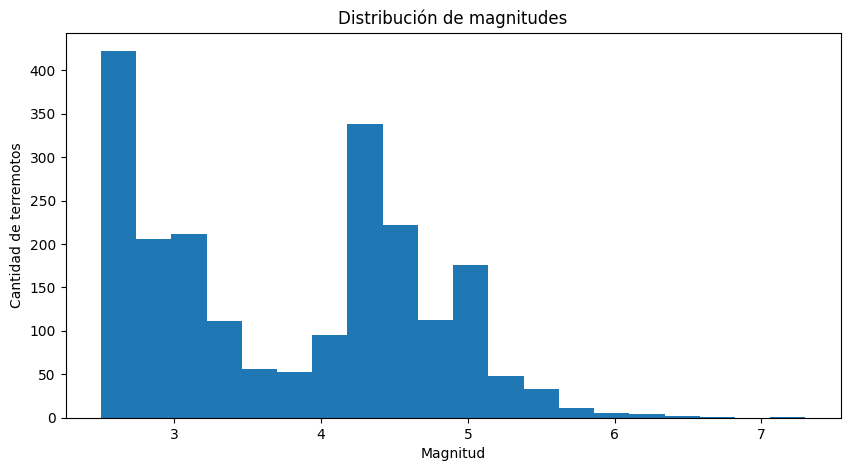

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_total["magnitud"].dropna(),
    bins=20
)

plt.xlabel("Magnitud")
plt.ylabel("Cantidad de terremotos")
plt.title("Distribución de magnitudes")

plt.show()

### Otra pregunta visual

¿Vemos alguna relación entre:

- magnitud
- profundidad?

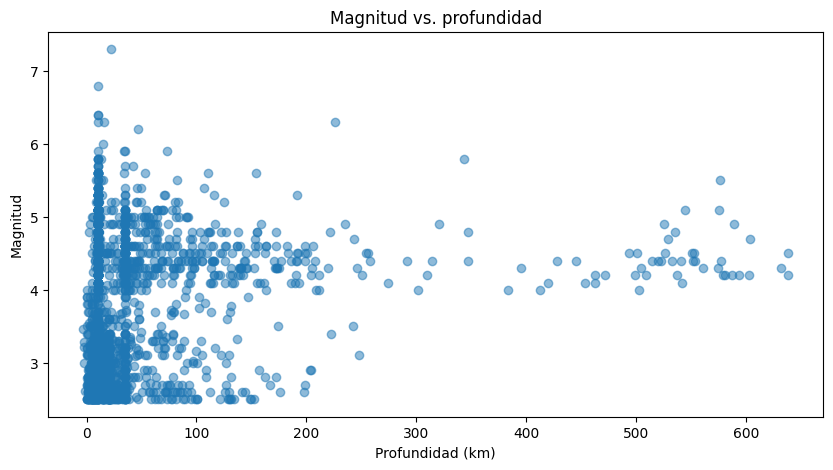

In [19]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_total["profundidad_km"],
    df_total["magnitud"],
    alpha=0.5
)

plt.xlabel("Profundidad (km)")
plt.ylabel("Magnitud")
plt.title("Magnitud vs. profundidad")

plt.show()

# 🧩 14. DESAFÍO FINAL

Ahora te toca a vos.

## 🕵️ Misión: Analista sísmico/a

Utilizando `df_total`, respondé:

### 1️⃣
¿Cuántos terremotos tienen magnitud igual o superior a 5?

### 2️⃣
¿Cuál fue el terremoto más profundo?

### 3️⃣
¿Cuál fue el día con mayor cantidad de terremotos?

### 4️⃣
¿Cuál es la magnitud promedio por `nivel`?

### 5️⃣
¿Qué porcentaje de los terremotos corresponde a la categoría "Fuerte" o "Muy fuerte"?

### ⭐ BONUS

Creá una función:

```python
buscar_terremotos(magnitud_minima)
```

que reciba una magnitud y devuelva solamente los terremotos que superen ese valor.

Ejemplo:

```python
buscar_terremotos(5)
```

debería devolver los terremotos con magnitud ≥ 5.

# 🎯 Solución del desafío

Intentá resolverlo antes de mirar esta parte 😉

In [20]:
# 1. Magnitud >= 5

fuertes = df_total[df_total["magnitud"] >= 5]

print("Terremotos con magnitud >= 5:", len(fuertes))


# 2. Terremoto más profundo

print("Terremoto más profundo:")
display(
    df_total.loc[df_total["profundidad_km"].idxmax()]
)


# 3. Día con mayor cantidad de terremotos

por_dia = (
    df_total
    .groupby("fecha")
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

print("Día con mayor cantidad:")
display(por_dia.head(1))


# 4. Magnitud promedio por nivel

promedio_nivel = (
    df_total
    .groupby("nivel")["magnitud"]
    .mean()
    .round(2)
    .reset_index()
)

promedio_nivel

Terremotos con magnitud >= 5: 211
Terremoto más profundo:


,550
id,us7000t1sy
magnitud,4.2
lugar,"241 km E of Levuka, Fiji"
timestamp,1784471335542
longitud,-178.4153
latitud,-17.8773
profundidad_km,637.734
fecha_hora,2026-07-19 14:28:55.542000+00:00
fecha,2026-07-19
nivel,Moderado


Día con mayor cantidad:


,fecha,cantidad
4,2026-07-17,136


,nivel,magnitud
0,Fuerte,5.22
1,Leve,2.93
2,Moderado,4.46
3,Muy fuerte,6.44


In [21]:
# 5. Porcentaje de terremotos fuertes o muy fuertes

porcentaje_fuertes = (
    df_total["nivel"]
    .isin(["Fuerte", "Muy fuerte"])
    .mean()
    * 100
)

print(
    f"Porcentaje de terremotos fuertes o muy fuertes: "
    f"{porcentaje_fuertes:.2f}%"
)

Porcentaje de terremotos fuertes o muy fuertes: 10.01%


In [22]:
# ⭐ BONUS

def buscar_terremotos(magnitud_minima):
    return df_total[
        df_total["magnitud"] >= magnitud_minima
    ].sort_values(
        "magnitud",
        ascending=False
    )

buscar_terremotos(5).head(10)

,id,magnitud,lugar,timestamp,longitud,latitud,profundidad_km,fecha_hora,fecha,nivel,descripcion,requiere_atencion
787,us7000t1bu,7.3,"52 km W of Puerto Madero, Mexico",1784299720227,-92.8969,14.6361,22.000,2026-07-17 14:48:40.227000+00:00,2026-07-17,Muy fuerte,Magnitud 6 o superior,Muy alta
1990,us6000tgb9,6.8,"The 2026 Kumamoto Region, Japan Earthquake",1785223635512,130.7217,32.6817,10.000,2026-07-28 07:27:15.512000+00:00,2026-07-28,Muy fuerte,Magnitud 6 o superior,Muy alta
779,us7000t1cc,6.4,"96 km SW of Puerto Madero, Mexico",1784301606587,-93.1385,14.2039,10.000,2026-07-17 15:20:06.587000+00:00,2026-07-17,Muy fuerte,Magnitud 6 o superior,Muy alta
1120,us7000szzy,6.4,"196 km SE of Lorengau, Papua New Guinea",1783932807219,148.5991,-3.2114,10.000,2026-07-13 08:53:27.219000+00:00,2026-07-13,Muy fuerte,Magnitud 6 o superior,Muy alta
1457,us6000ti8i,6.3,south of the Kermadec Islands,1785915807317,179.4727,-33.8063,226.084,2026-08-05 07:43:27.317000+00:00,2026-08-05,Muy fuerte,Magnitud 6 o superior,Muy alta
1103,us7000t01n,6.3,southeast of the Loyalty Islands,1783953949630,171.5534,-22.7876,16.000,2026-07-13 14:45:49.630000+00:00,2026-07-13,Muy fuerte,Magnitud 6 o superior,Muy alta
1471,us6000ti6x,6.3,"32 km SW of Sarangani, Philippines",1785903246625,125.2760,5.1812,10.000,2026-08-05 04:14:06.625000+00:00,2026-08-05,Muy fuerte,Magnitud 6 o superior,Muy alta
1015,us7000t0d0,6.2,"32 km WSW of Sarangani, Philippines",1784044179287,125.1810,5.3206,47.171,2026-07-14 15:49:39.287000+00:00,2026-07-14,Muy fuerte,Magnitud 6 o superior,Muy alta
164,us7000t37a,6.0,"55 km W of Sola, Vanuatu",1784929071697,167.0409,-13.9559,15.000,2026-07-24 21:37:51.697000+00:00,2026-07-24,Muy fuerte,Magnitud 6 o superior,Muy alta
890,us7000t0xb,5.9,"44 km NNW of Te Anau, New Zealand",1784193293985,167.5447,-45.0319,73.615,2026-07-16 09:14:53.985000+00:00,2026-07-16,Fuerte,Magnitud entre 5 y 5.9,Alta


# 🎉 Cierre

Hoy recorrimos un pipeline muy parecido al que aparece en proyectos reales:

```text
🌎 FUENTE DE DATOS
      ↓
🚪 API
      ↓
📦 JSON
      ↓
🐼 DATAFRAME
      ↓
🧹 WRANGLING
      ↓
➕ CONCAT
      ↓
🔗 MERGE
      ↓
📊 ANÁLISIS
      ↓
💡 PREGUNTAS
```

### Y una idea importante:

> **Data Science no empieza con un algoritmo.**
>
> Empieza con una pregunta y con datos que podamos transformar para intentar responderla.